## In the notebook, please use the qnn-onnx-converter with QNN 2.18. For the rest of the qnn commands, you can use QNN 2.21

In [ ]:
%%cmd
git clone https://github.com/csqiangwen/DeepFillv2_Pytorch

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>git clone https://github.com/csqiangwen/DeepFillv2_Pytorch


Cloning into 'DeepFillv2_Pytorch'...



C:\Qualcomm\AIStack\models\image-inpaint>

In [ ]:
%%cmd
copy assets\onnx_export.patch DeepFillv2_Pytorch
cd DeepFillv2_Pytorch
git apply onnx_export.patch

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>copy assets\onnx_export.patch DeepFillv2_Pytorch
        1 file(s) copied.

C:\Qualcomm\AIStack\models\image-inpaint>cd DeepFillv2_Pytorch

C:\Qualcomm\AIStack\models\image-inpaint\DeepFillv2_Pytorch>git apply onnx_export.patch


onnx_export.patch:86: trailing whitespace.
   
onnx_export.patch:129: trailing whitespace.
    
onnx_export.patch:86: new blank line at EOF.
+



C:\Qualcomm\AIStack\models\image-inpaint\DeepFillv2_Pytorch>

In [ ]:
%%cmd
cd DeepFillv2_Pytorch
mkdir pretrained_model


Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd DeepFillv2_Pytorch

C:\Qualcomm\AIStack\models\image-inpaint\DeepFillv2_Pytorch>mkdir pretrained_model

C:\Qualcomm\AIStack\models\image-inpaint\DeepFillv2_Pytorch>

#### Download model from https://drive.google.com/u/0/uc?id=1uMghKl883-9hDLhSiI8lRbHCzCmmRwV-&export=download and move to pretrained_model

In [ ]:
!pip install imgcrop

  Using cached imgcrop-0.1.0-py3-none-any.whl.metadata (5.7 kB)
Using cached imgcrop-0.1.0-py3-none-any.whl (4.9 kB)


In [ ]:
%%cmd
cd DeepFillv2_Pytorch
python test.py

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd DeepFillv2_Pytorch

C:\Qualcomm\AIStack\models\image-inpaint\DeepFillv2_Pytorch>python test.py


C:\Ashwath\envs\acer_python3.10_qnn2.23\lib\site-packages\torch\onnx\_internal\jit_utils.py:307: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at ..\torch\csrc\jit\passes\onnx\constant_fold.cpp:181.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
C:\Ashwath\envs\acer_python3.10_qnn2.23\lib\site-packages\torch\onnx\utils.py:702: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at ..\torch\csrc\jit\passes\onnx\constant_fold.cpp:181.)
  _C._jit_pass_onnx_graph_shape_type_inference(
C:\Ashwath\envs\acer_python3.10_qnn2.23\lib\site-packages\torch\onnx\utils.py:1209: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at ..\torch\csrc\jit\passes\onnx\const

Generator is created!
Initialize generator with xavier type
The overall number of images equals to 0

C:\Qualcomm\AIStack\models\image-inpaint\DeepFillv2_Pytorch>

In [ ]:
import torch
import cv2
import numpy as np
import os

In [ ]:
def load_img(img_path,mask_path):
    im = cv2.imread(img_path)
    mk = cv2.imread(mask_path)[:, :, 0]
    im = cv2.resize(im, (512, 512), 
               interpolation = cv2.INTER_LINEAR)
    mk = cv2.resize(mk, (512, 512), 
               interpolation = cv2.INTER_LINEAR)
    
    
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    im = torch.from_numpy(im.astype(np.float32) / 255.0).permute(2, 0, 1).contiguous()
    mk = torch.from_numpy(mk.astype(np.float32) / 255.0).unsqueeze(0).contiguous()
    return im, mk

def create_raw(im,mk,i):
    out_image = im.unsqueeze(0)
    out_mask = mk.unsqueeze(0)
    img = out_image.numpy()
    mask = out_mask.numpy()
    img = np.transpose(img,(0,2,3,1))
    mask = np.transpose(mask,(0,2,3,1))
    raw_img_path = "assets/raw/image"+str(i)+".raw"
    raw_mask_path = "assets/raw/mask"+str(i)+".raw"
    img.tofile(raw_img_path)
    mask.tofile(raw_mask_path)
    print(img.shape)
    print(mask.shape)
    return out_image,out_mask

In [ ]:
%%cmd
cd assets
mkdir raw

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>mkdir raw

C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [ ]:
out_image = []
out_mask = []

for i in range(1,6):
    img_path = "DeepFillv2_Pytorch/test_data/"+str(i+1)+".png"
    mask_path = "DeepFillv2_Pytorch/test_data_mask/"+str(i+1)+".png"
    im, mk = load_img(img_path,mask_path)
    oi,om =  create_raw(im,mk,i+1)
    out_image.append(oi)
    out_mask.append(om)

(1, 512, 512, 3)
(1, 512, 512, 1)
(1, 512, 512, 3)
(1, 512, 512, 1)
(1, 512, 512, 3)
(1, 512, 512, 1)
(1, 512, 512, 3)
(1, 512, 512, 1)
(1, 512, 512, 3)
(1, 512, 512, 1)


In [ ]:
with open("assets/input_list.txt",'w') as f:
    for i in range(2,4):
        f.write(f"onnx::Mul_0:=raw/image{i}.raw mask:=raw/mask{i}.raw\n")

In [ ]:
os.environ['QNN_ROOT']="C:\\Qualcomm\\AIStack\\QAIRT\\2.23.0.240531"
os.environ['PYTHONPATH']= "C:\\Qualcomm\\AIStack\\QAIRT\\2.23.0.240531\\lib\\python"
os.environ['PATH']=os.environ['PATH']+"C:\\Qualcomm\\AIStack\\QAIRT\\2.23.0.240531\\bin\\aarch64-windows-msvc"

In [ ]:
import shutil
SDK_dir = "C:\\Qualcomm\\AIStack\\QAIRT\\2.23.0.240531"       # Specify what's QNN SDK used
SDK_lib_dir = SDK_dir + "\\lib\\arm64x-windows-msvc"
SDK_skel = SDK_dir + "\\lib\\hexagon-v73\\unsigned"

# Copy necessary libraries to a common location
libs = ["QnnCpu.dll","QnnHtp.dll", "QnnSystem.dll", "QnnHtpNetRunExtensions.dll", "QnnHtpPrepare.dll", "QnnHtpV73Stub.dll"]
for lib in libs:
    print(SDK_lib_dir)
    shutil.copy(SDK_lib_dir + "\\" + lib, "assets")
# skel_libs = ["libqnnhtpv73.cat", "libQnnHtpV73.so", "libQnnHtpV73Skel.so"]      # No .cat file in QNN 2.23
skel_libs = ["libQnnHtpV73.so", "libQnnHtpV73Skel.so"]
# Copy Skel
for lib in skel_libs:
    shutil.copy(SDK_skel + "\\" + lib, "assets")

C:\Qualcomm\AIStack\QAIRT\2.23.0.240531\lib\arm64x-windows-msvc
C:\Qualcomm\AIStack\QAIRT\2.23.0.240531\lib\arm64x-windows-msvc
C:\Qualcomm\AIStack\QAIRT\2.23.0.240531\lib\arm64x-windows-msvc
C:\Qualcomm\AIStack\QAIRT\2.23.0.240531\lib\arm64x-windows-msvc
C:\Qualcomm\AIStack\QAIRT\2.23.0.240531\lib\arm64x-windows-msvc
C:\Qualcomm\AIStack\QAIRT\2.23.0.240531\lib\arm64x-windows-msvc


In [ ]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.23.0.240531\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\deepfillv2.onnx" -o "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\float32\\deepfillv2.cpp" 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.23.0.240531\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\deepfillv2.onnx" -o "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\float32\\deepfillv2.cpp" 


Traceback (most recent call last):
  File "C:\Qualcomm\AIStack\QAIRT\2.23.0.240531\bin\arm64x-windows-msvc\qnn-onnx-converter", line 12, in <module>
    from qti.aisw.converters import onnx as onnx_frontend
ModuleNotFoundError: No module named 'qti'



C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [ ]:
json_str = """{
    "graphs": {
        "vtcm_mb":8,
        "graph_names":[],
        "O":3.0
    },
    "devices": [
        {
            "soc_id": 60,
            "dsp_arch": "v73",
            "cores":[{
                "core_id": 0,
                "perf_profile": "burst",
                "rpc_control_latency":100
            }]
        }
    ]
}"""
f = open(".\\assets\\htp_backend_extensions.json", "w")
f.write(json_str)
f.close()

In [80]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.23.0.240531\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\deepfillv2.onnx" --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\int8\\deepfillv2.cpp" --config_file "htp_backend_extensions.json" 

Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>python "C:\Qualcomm\AIStack\QNN\2.18.0.240101\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\deepfillv2.onnx" --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\int8\\deepfillv2.cpp" 


2024-03-19 07:53:12,174 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /coarse/coarse.0/pad/Concat_output_0: new name /coarse/coarse.0/pad/Reshape_output_0 new shape [-1, 2]
2024-03-19 07:53:12,181 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /coarse/coarse.0/pad/Slice_output_0: new name /coarse/coarse.0/pad/Transpose_output_0 new shape (2, 4)
2024-03-19 07:53:12,185 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /coarse/coarse.0/pad/Transpose_output_0: new name /coarse/coarse.0/pad/Reshape_1_output_0 new shape [-1]
2024-03-19 07:53:12,187 - 240 - WARNING - WARNING_CAST_TYPE: Only numerical type cast is supported. The op: /coarse/coarse.0/pad/Cast will be interpreted at conversion time
2024-03-19 07:53:12,207 - 235 - INFO - INFO_STATIC_RESHAPE: Applying static reshape to /coarse/coarse.1/pad/Concat_output_0: new name /coarse/coarse.1/pad/Reshape_output_0 new shape [-1, 2]
2024-03-19 07:53:12,209 - 235 - INFO - INFO_STATIC_RESHAPE: Apply

    28.4ms [  INFO ] Inferences will run in sync mode
    31.0ms [  INFO ] Initializing logging in the backend. Callback: [00007FFB25585740], Log Level: [3]
    31.0ms [  INFO ] No BackendExtensions lib provided;initializing NetRunBackend Interface
    32.5ms [WARNING] Unable to find a device with NetRunDeviceKeyDefault in Library NetRunBackendLibKeyDefault
    33.3ms [  INFO ] Entering QuantizeRuntimeApp flow
   448.1ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::finalize
  2105.9ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::execute
 53603.7ms [  INFO ] cleaning up resources for input tensors
 53604.5ms [  INFO ] cleaning up resources for output tensors
 53738.9ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::execute
103075.1ms [  INFO ] cleaning up resources for input tensors
103075.8ms [  INFO ] cleaning up resources for output tensors
103651.5ms [  INFO ] Freeing graphsInfo

C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [81]:
%%cmd
cd assets
mkdir "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs"
python "C:\Qualcomm\AIStack\QAIRT\\2.23.0.240531\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\float32\\deepfillv2.cpp" -b "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\float32\\deepfillv2.bin" -o "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\float32\\" -t windows-aarch64

Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>mkdir "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs"



A subdirectory or file C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs already exists.


C:\Qualcomm\AIStack\models\image-inpaint\assets>python "C:\Qualcomm\AIStack\QNN\2.18.0.240101\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\float32\\deepfillv2.cpp" -b "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\float32\\deepfillv2.bin" -o "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\float32\\" -t windows-aarch64


2024-03-19 07:55:08,197 -    INFO - qnn-model-lib-generator: Model SDK file path  : C:\Qualcomm\AIStack\QNN\2.18.0.240101
2024-03-19 07:55:08,197 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\float32\\deepfillv2.cpp
2024-03-19 07:55:08,197 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\float32\\deepfillv2.bin
2024-03-19 07:55:08,197 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-03-19 07:55:08,197 -    INFO - qnn-model-lib-generator: Library name         : None
2024-03-19 07:55:08,197 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\float32\
2024-03-19 07:55:08,198 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-03-19 07:55:08,198 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-03-19 07:55:08,


C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [82]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.23.0.240531\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\int8\\deepfillv2.cpp" -b "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\int8\\deepfillv2.bin" -o "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\int8\\" -t windows-aarch64 

Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>python "C:\Qualcomm\AIStack\QNN\2.18.0.240101\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\int8\\deepfillv2.cpp" -b "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\int8\\deepfillv2.bin" -o "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\int8\\" -t windows-aarch64 


2024-03-19 07:58:13,966 -    INFO - qnn-model-lib-generator: Model SDK file path  : C:\Qualcomm\AIStack\QNN\2.18.0.240101
2024-03-19 07:58:13,967 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\int8\\deepfillv2.cpp
2024-03-19 07:58:13,967 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\int8\\deepfillv2.bin
2024-03-19 07:58:13,967 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-03-19 07:58:13,967 -    INFO - qnn-model-lib-generator: Library name         : None
2024-03-19 07:58:13,967 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\int8\
2024-03-19 07:58:13,968 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-03-19 07:58:13,968 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-03-19 07:58:13,968 -    


C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [96]:
%%cmd
cd assets
qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\int8\ARM64\deepfillv2.dll"  --backend "QnnHtp.dll" --binary_file deepfillv2.serialized
move  output\deepfillv2.serialized.bin "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\deepfillv2.serialized.v73.bin"

Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\int8\ARM64\deepfillv2.dll"  --backend "QnnHtp.dll" --binary_file deepfillv2.serialized
qnn-context-binary-generator pid:16604
Starting stage: Graph Preparation Initializing
Completed stage: Graph Preparation Initializing (295 us)
Starting stage: Graph Transformations and Optimizations
Completed stage: Graph Transformations and Optimizations (4266870 us)
Starting stage: Graph Sequencing for Target
 [##################################################] 100%
Completed stage: Graph Sequencing for Target (37244389 us)
Starting stage: VTCM Allocation
Completed stage: VTCM Allocation (24946560 us)
Starting stage: Parallelization Optimization
Completed stage: Parallelization Optimization (627891 us)
Sta

In [105]:
%%cmd 
cd assets
rmdir /s  output_cpu
Y
rmdir /s  output_dsp 
Y

Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>rmdir /s  output_cpu
output_cpu, Are you sure (Y/N)? Y

C:\Qualcomm\AIStack\models\image-inpaint\assets>rmdir /s  output_dsp 
output_dsp, Are you sure (Y/N)? Y

C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [106]:
%%cmd
cd assets
qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\float32\ARM64\deepfillv2.dll" --input_list input_list.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\model_libs\\float32\ARM64\deepfillv2.dll" --input_list input_list.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:16980

C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [107]:
%%cmd
cd assets
qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\deepfillv2.serialized.v73.bin" --input_list input_list.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\image-inpaint\\assets\\deepfillv2.serialized.v73.bin" --input_list input_list.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:22904
     0.0ms [WARNING] QnnDsp <W> Function not called, PrepareLib isn't loaded!


C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [108]:
%%cmd
cd assets
mkdir output
mkdir output\cpu
mkdir output\dsp

Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>mkdir output


A subdirectory or file output already exists.



C:\Qualcomm\AIStack\models\image-inpaint\assets>mkdir output\cpu


A subdirectory or file output\cpu already exists.



C:\Qualcomm\AIStack\models\image-inpaint\assets>mkdir output\dsp


A subdirectory or file output\dsp already exists.



C:\Qualcomm\AIStack\models\image-inpaint\assets>

In [114]:
def save_sample_png(sample_name, img_list, pixel_max_cnt = 255):
    for i in range(len(img_list)):
        img = img_list[i]
        img = img * 255
        img_copy = img.clone().data.permute(0, 2, 3, 1)[0, :, :, :].cpu().numpy()
        img_copy = np.clip(img_copy, 0, pixel_max_cnt)
        img_copy = img_copy.astype(np.uint8)
        img_copy = cv2.cvtColor(img_copy, cv2.COLOR_RGB2BGR)
        # Save to certain path
        save_img_name = sample_name + '.png'
        save_img_path =  save_img_name
        cv2.imwrite(save_img_path, img_copy)

In [115]:
def postProcess(output_path, sample_name, i):
    
    output = np.fromfile(output_path, dtype=np.float32)
    output = output.reshape((1,512,512,3)).astype(np.float32)
    output = np.transpose(output,(0,3,1,2))
    output = torch.from_numpy(output)
    print(output.shape)
    
    second_out_wholeimg = out_image[i] * (1 - out_mask[i]) + output * out_mask[i]      # in range [0, 1]
    img_list = [second_out_wholeimg]
    save_sample_png(sample_name,img_list, pixel_max_cnt = 255)


In [116]:
for i in range(2):
    sample_name = "assets/output/cpu/"+str(i+2)+"_cpu"
    output_path = "assets/output_cpu/Result_"+str(i)+"/_1460.raw"
    postProcess(output_path, sample_name, i)

torch.Size([1, 3, 512, 512])
torch.Size([1, 3, 512, 512])


In [117]:
for i in range(2):
    sample_name = "assets/output/dsp/"+str(i+2)+"_dsp"
    output_path = "assets/output_dsp/Result_"+str(i)+"/_1460.raw"
    postProcess(output_path, sample_name, i)

torch.Size([1, 3, 512, 512])
torch.Size([1, 3, 512, 512])


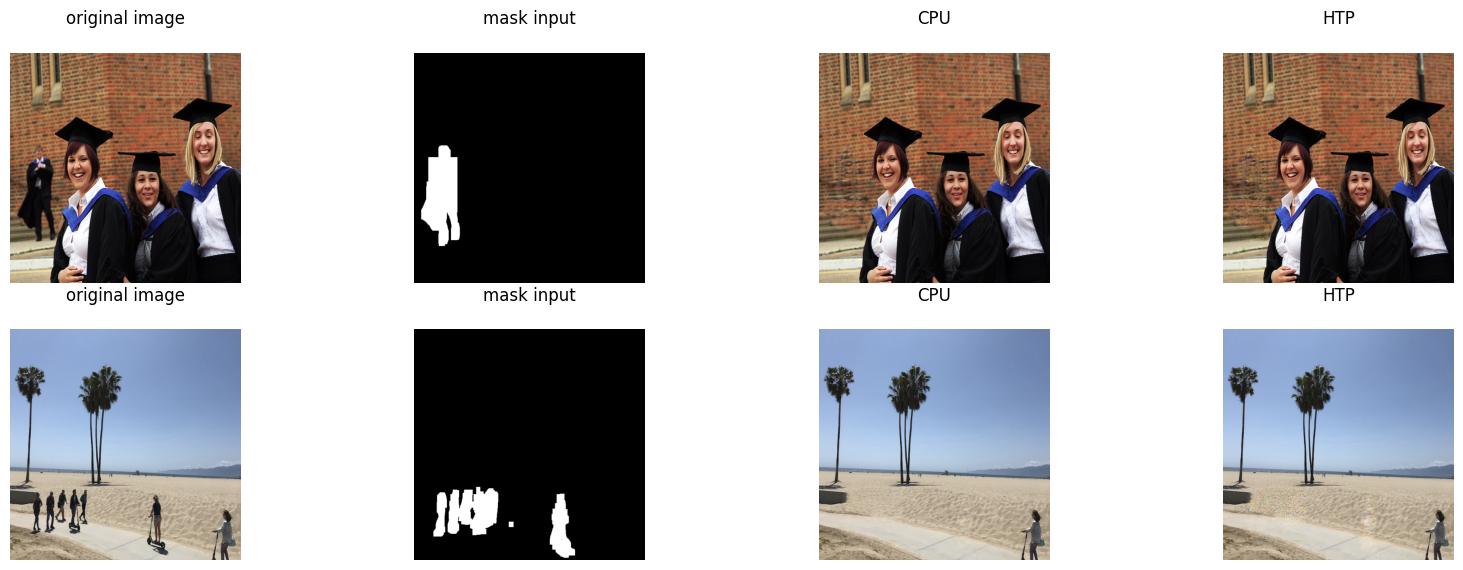

In [118]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20, 100));
import cv2
for i in range(2,4):
    
    original = cv2.imread("DeepFillv2_Pytorch/test_data/"+str(i)+'.png')
    original = cv2.resize(original, (512,512))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    ax = fig.add_subplot(28,4,4*i+1);
    plt.imshow(original,cmap='gray');
    ax.set_title('original image\n');
    ax.axis('off');
    
    pth_inf = cv2.imread('DeepFillv2_Pytorch/test_data_mask/'+str(i)+'.png')
    pth_inf = cv2.resize(pth_inf, (512,512))

    ax = fig.add_subplot(28,4,4*i+2);
    plt.imshow(pth_inf,cmap='gray');
    ax.set_title('mask input\n');
    ax.axis('off');


    arm_fp32= cv2.imread('assets/output/cpu/'+str(i)+'_cpu.png')
    arm_fp32 = cv2.cvtColor(arm_fp32, cv2.COLOR_BGR2RGB)
    arm_fp32 = cv2.resize(arm_fp32, (512,512))
    ax = fig.add_subplot(28,4,4*i+3);
    plt.imshow(arm_fp32,cmap='gray');
    ax.set_title('CPU\n');
    ax.axis('off');

    dsp= cv2.imread('assets/output/dsp/'+str(i)+'_dsp.png')
    dsp = cv2.cvtColor(dsp, cv2.COLOR_BGR2RGB)

    ax = fig.add_subplot(28,4,4*i+4);
    plt.imshow(dsp,cmap='gray');
    ax.set_title('HTP\n');
    ax.axis('off');

In [119]:
%%cmd
cd assets
qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log


Microsoft Windows [Version 10.0.25936.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\image-inpaint>cd assets

C:\Qualcomm\AIStack\models\image-inpaint\assets>qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log
Log File Created: Tue Mar 19 08:14:10 2024
Time Scale: 1e-06
Epoch Timestamp: 1710861250848548 Steady Clock Timestamp: 1133237894233
Generated using: 
qnn-profile-viewer v2.18.0.231229151826_79175
qnn-net-run        v2.18.0.231229151826_79175
Backend            v2.18.0.231229151826_79175

Qnn Init/Prepare/Finalize/De-Init/Execute/Lib-Load Statistics:
------------------------------------------------------------
Init Stats:
-----------
    NetRun: 73530 us
    Backend (RPC (load binary) time): 58760 us
    Backend (QNN accelerator (load binary) time): 56691 us
    Backend (Accelerator (load binary) time): 55607 us
    Backend (QNN (load binary) time): 73496 us

Compose Graphs Stats:
--------------
    NetRun: 0 us

Finalize Stats:
-